In [36]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cpu


Now importing my dataset from my google drive

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
if not os.path.exists('/content/Fruits'):
    !cp -r /content/drive/MyDrive/fruits_dataset/Fruits /content/Fruits

In [38]:
import os
dataset_path = '/content/Fruits'
print("Dataset path exists:", os.path.exists(dataset_path))
print("First 15 folders:", os.listdir(dataset_path)[:15])

Dataset path exists: True
First 15 folders: ['Banana', 'Apple', 'Plum', 'Pitaya', 'Orange', 'Carambola', 'Tomatoes', 'Pear', 'Mango', 'muskmelon', 'Peach', 'Guava', 'Pomegranate', 'Persimmon', 'Kiwi']


Ensuring pytorch can read this fully

In [39]:
full_dataset = datasets.ImageFolder(dataset_path)

print("Number of classes:", len(full_dataset.classes))
print("First 15 classes:", full_dataset.classes[:15])
print("Total images:", len(full_dataset))

Number of classes: 15
First 15 classes: ['Apple', 'Banana', 'Carambola', 'Guava', 'Kiwi', 'Mango', 'Orange', 'Peach', 'Pear', 'Persimmon', 'Pitaya', 'Plum', 'Pomegranate', 'Tomatoes', 'muskmelon']
Total images: 44406


jdbc

In [40]:
# =========================
# 5. Transforms
# =========================
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),          # resize
    transforms.RandomHorizontalFlip(),    # flip
    transforms.RandomRotation(15),        # rotate
    transforms.ColorJitter(0.2, 0.2, 0.2),# color change
    transforms.ToTensor()                 # to tensor
])

val_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),          # resize
    transforms.ToTensor()                 # to tensor
])

# =========================
# 6. Split dataset
# =========================
full_dataset = datasets.ImageFolder(dataset_path, transform=None)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # fixed split
)

class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

train_data = TransformedSubset(train_subset, transform=train_transform)
val_data = TransformedSubset(val_subset, transform=val_test_transform)
test_data = TransformedSubset(test_subset, transform=val_test_transform)

print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))

Train: 31084
Val: 6660
Test: 6662


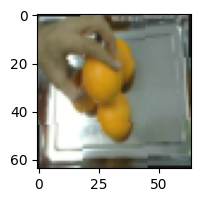

In [41]:
#generating random image from dataset

idx = np.random.randint(0, len(train_data))
plt.figure(figsize = (2,2))
plt.imshow(train_data[idx][0].permute(1,2,0))

In [42]:
#important HyperParameters
batch_size = 64
learning_rate=0.001
minimum_learning_rate=1e-4
epochs = 10

In [43]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
# ==============================
# Custom CNN Model
# ==============================

class CNNModel(nn.Module):
    def __init__(self, num_classes=len(full_dataset.classes)):
        super(CNNModel, self).__init__()

        # Convolutional layers
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3),
            nn.BatchNorm2d(64),      # normalization
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*6*6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),         # regularization
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize model
model = CNNModel().to(device)

# Optimizer
optimizer = Adam(model.parameters(), lr=learning_rate)
#This creates a learning rate scheduler.
# Learning rate scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=minimum_learning_rate)

# Loss function
criterion = nn.CrossEntropyLoss()

from torchsummary import summary
summary(model, input_size=(3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 62, 62]           1,792
       BatchNorm2d-2           [-1, 64, 62, 62]             128
              ReLU-3           [-1, 64, 62, 62]               0
         MaxPool2d-4           [-1, 64, 31, 31]               0
            Conv2d-5          [-1, 128, 29, 29]          73,856
       BatchNorm2d-6          [-1, 128, 29, 29]             256
              ReLU-7          [-1, 128, 29, 29]               0
         MaxPool2d-8          [-1, 128, 14, 14]               0
            Conv2d-9          [-1, 128, 12, 12]         147,584
      BatchNorm2d-10          [-1, 128, 12, 12]             256
             ReLU-11          [-1, 128, 12, 12]               0
        MaxPool2d-12            [-1, 128, 6, 6]               0
          Flatten-13                 [-1, 4608]               0
           Linear-14                  [

In [45]:
# ==============================
# Training function (one epoch)
# ==============================

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()          # reset gradients
        outputs = model(images)        # forward pass
        loss = criterion(outputs, labels)

        loss.backward()                # backpropagation
        optimizer.step()               # update weights

        total_loss += loss.item()

        # Accuracy calculation
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


# ==============================
# Validation function
# ==============================

def validate_epoch(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

In [46]:
# ==============================
# Training loop
# ==============================

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_acc = 0

for epoch in range(epochs):
    print("----------------------------------------------------")
    print(f"Epoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    scheduler.step()

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

----------------------------------------------------
Epoch 1/10
Train Loss: 1.0842 | Train Acc: 0.6206
Val Loss:   0.6713 | Val Acc:   0.7568
----------------------------------------------------
Epoch 2/10
Train Loss: 0.5211 | Train Acc: 0.8209
Val Loss:   0.2481 | Val Acc:   0.9111
----------------------------------------------------
Epoch 3/10
Train Loss: 0.3624 | Train Acc: 0.8736
Val Loss:   0.1903 | Val Acc:   0.9372
----------------------------------------------------
Epoch 4/10
Train Loss: 0.2835 | Train Acc: 0.9038
Val Loss:   0.1481 | Val Acc:   0.9483
----------------------------------------------------
Epoch 5/10
Train Loss: 0.2329 | Train Acc: 0.9230
Val Loss:   0.0925 | Val Acc:   0.9683
----------------------------------------------------
Epoch 6/10
Train Loss: 0.1806 | Train Acc: 0.9395
Val Loss:   0.0959 | Val Acc:   0.9668
----------------------------------------------------
Epoch 7/10
Train Loss: 0.1512 | Train Acc: 0.9501
Val Loss:   0.1056 | Val Acc:   0.9613
------

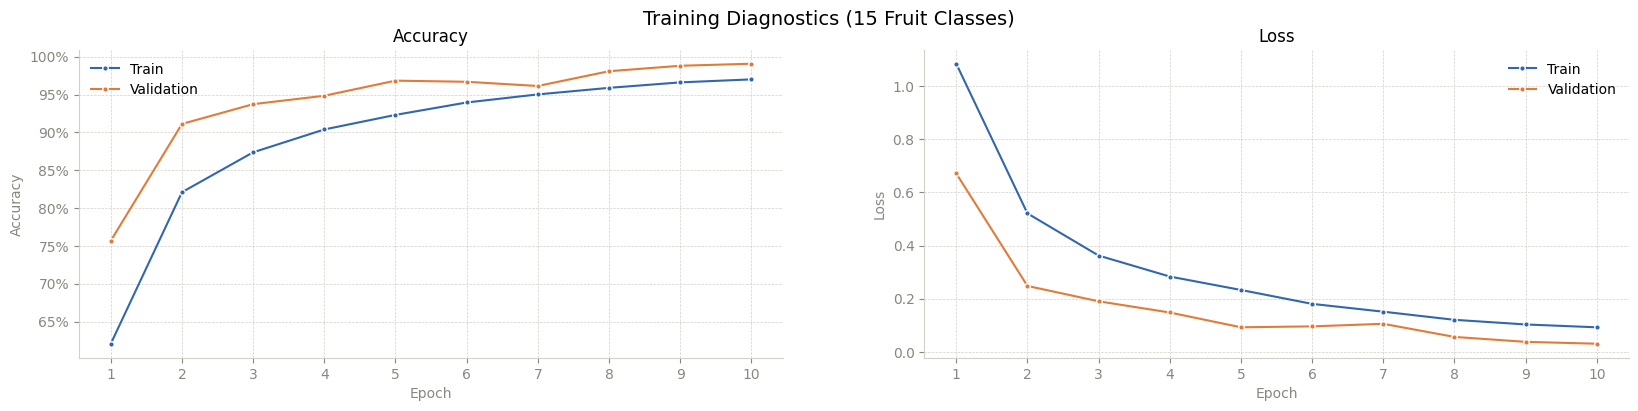

In [54]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np

BLUE   = "#3266ad"
ORANGE = "#e07b39"
GRAY   = "#88877f"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#d3d1c7",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#d3d1c7",
    "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "xtick.color": GRAY,
    "ytick.color": GRAY,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Automatically match epochs to data
epochs = len(train_accuracies)
epochs_number = np.arange(1, epochs + 1)

fig = plt.figure(figsize=(20, 4))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

# ── Accuracy ─────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_number, train_accuracies, color=BLUE, label="Train", marker="o", ms=4, mec="white")
ax1.plot(epochs_number, val_accuracies,   color=ORANGE, label="Validation", marker="o", ms=4, mec="white")

ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))

ax1.set_xlabel("Epoch", color=GRAY)
ax1.set_ylabel("Accuracy", color=GRAY)
ax1.set_title("Accuracy")
ax1.legend(frameon=False)

# ── Loss ─────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_number, train_losses, color=BLUE, label="Train", marker="o", ms=4, mec="white")
ax2.plot(epochs_number, val_losses,   color=ORANGE, label="Validation", marker="o", ms=4, mec="white")

ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))

ax2.set_xlabel("Epoch", color=GRAY)
ax2.set_ylabel("Loss", color=GRAY)
ax2.set_title("Loss")
ax2.legend(frameon=False)

fig.suptitle("Training Diagnostics (15 Fruit Classes)", fontsize=14)
plt.show()

In [48]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [49]:
# ==============================
# Load best model
# ==============================

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []

# ==============================
# Evaluate on test set
# ==============================

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ==============================
# Compute metrics
# ==============================

test_acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted"
)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-score      : {f1:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test Accuracy : 0.9917
Precision     : 0.9918
Recall        : 0.9917
F1-score      : 0.9917


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Total misclassified samples: 55


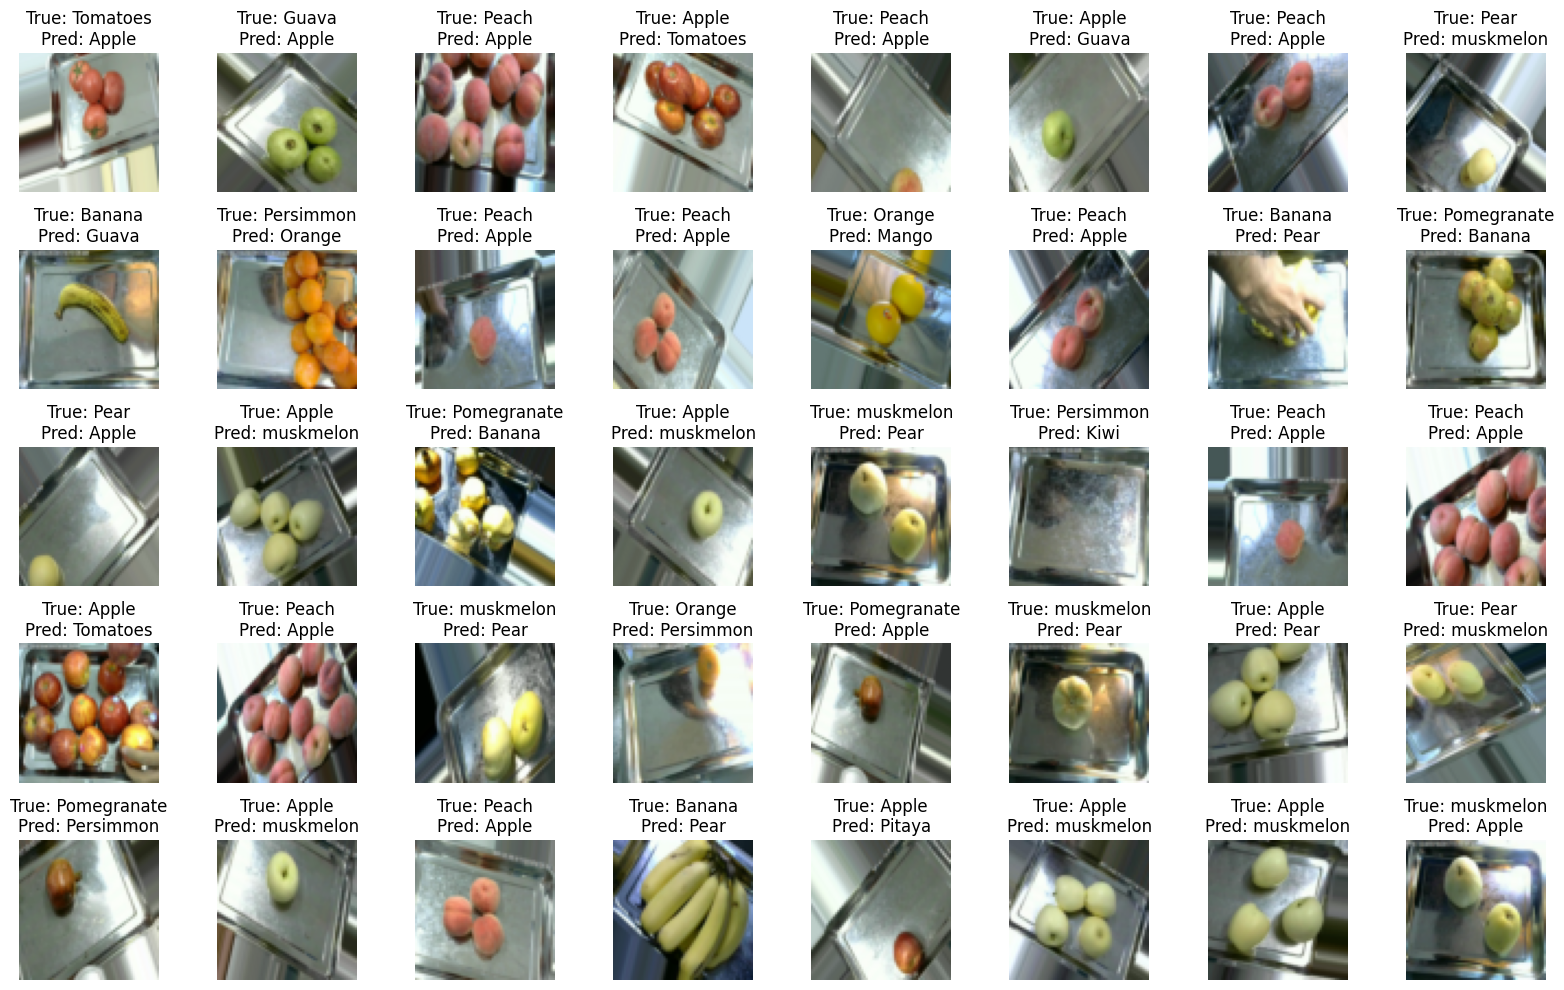

In [59]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

class_names = full_dataset.classes  # class names

model.eval()
misclassified = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:   # used test_loader
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # save predictions and true labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # save wrong predictions
        for img, true, pred in zip(images, labels, preds):
            if true != pred:
                misclassified.append((img.cpu(), true.cpu(), pred.cpu()))

print(f"Total misclassified samples: {len(misclassified)}")

num_rows = 5
num_cols = 8
num_to_show = min(num_rows * num_cols, len(misclassified))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
axes = axes.flatten()

for idx in range(num_to_show):
    img, true, pred = misclassified[idx]
    img = img.permute(1, 2, 0).numpy()   # C,H,W -> H,W,C

    axes[idx].imshow(img)
    axes[idx].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
    axes[idx].axis('off')

# hide extra empty plots
for idx in range(num_to_show, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [51]:
from sklearn.metrics import confusion_matrix

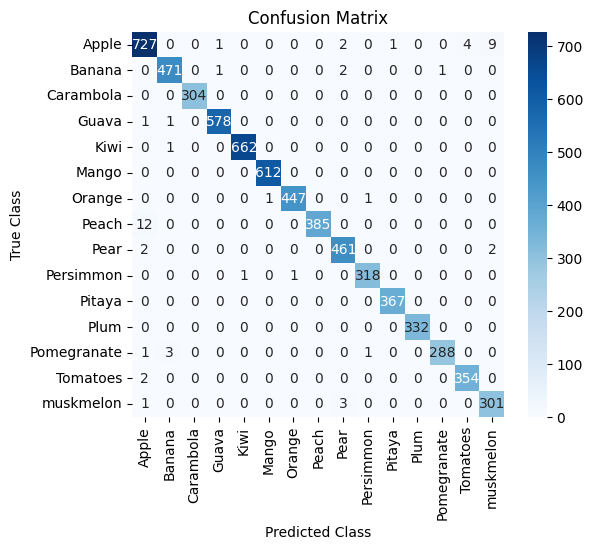

In [53]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

**Analysis and discussion of result**

The suggested CNN model worked well for the image classification task, getting a high accuracy score on the validation dataset. The training process showed stable convergence, with loss going down steadily over epochs. This means that the model learned useful features from the input data.

The analysis of the confusion matrix showed that most of the predictions were correct, and that most classes did very well. But there were a few mistakes, especially between classes that looked similar to each other. This means that the model works well in most situations, but it has trouble telling apart small differences.

When we looked more closely at the misclassified samples, we found that mistakes were often linked to unclear features, changes in lighting, and background noise.

A small difference between training and validation performance suggests mild overfitting, which means that the model might work better with more regularization methods like dropout or data augmentation.

The CNN model works effectively overall and is good at classifying things, but it could be better at generalizing and making fewer mistakes in classes that look similar.
